# Unpack and interpret inference of card instances in unseen SouthCamera video

In [7]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import sleap_io as sio
from IPython.display import Video, display, Markdown

In [35]:
PREDICTION_SLP = Path(
    "/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/south_camera_inference/predictions/CameraSouth_2026-04-14T14-00-00.avi_abcEphysPilot01_unseen_labels.v001.slp.260416_132201.predictions.slp"
)

EXPORT_DIR = Path(
    "/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/south_camera_inference/exports"
)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


In [36]:
labels = sio.load_file(PREDICTION_SLP)
video = labels.videos[0]

print("Frames with predictions:", len(labels.labeled_frames))
print("Video path:", video.filename)


Frames with predictions: 6797
Video path: /Volumes/aeon/aeon/data/raw/AEON3/abcEphysPilot01/2026-04-14T141851Z_calibrateBeforeAprilExperiments/CameraSouth/CameraSouth_2026-04-14T14-00-00.avi


In [37]:
video_path = video.filename

cap = cv2.VideoCapture(video_path)
ok, frame = cap.read()
cap.release()

if not ok:
    raise RuntimeError("Could not read first frame from video.")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


In [38]:
rows = []

for lf in labels.labeled_frames:
    for inst_idx, inst in enumerate(lf.instances):
        for pt in inst.points:
            rows.append(
                {
                    "frame_idx": lf.frame_idx,
                    "instance_idx": inst_idx,
                    "node_name": pt["name"],
                    "x": float(pt["xy"][0]),
                    "y": float(pt["xy"][1]),
                    "score": float(pt["score"]),
                    "visible": bool(pt["visible"]),
                }
            )

points_df = pd.DataFrame(rows)
points_df.head()

,frame_idx,instance_idx,node_name,x,y,score,visible
0,6093,0,corner_1,392.267029,1053.006226,0.617341,True
1,6093,0,corner_2,428.568848,1052.376465,0.309840,True
2,6093,0,corner_3,NaN,NaN,0.000000,False
3,6093,0,corner_4,392.297852,1076.467773,0.632924,True
4,6094,0,corner_1,395.707672,1048.883911,0.451408,True


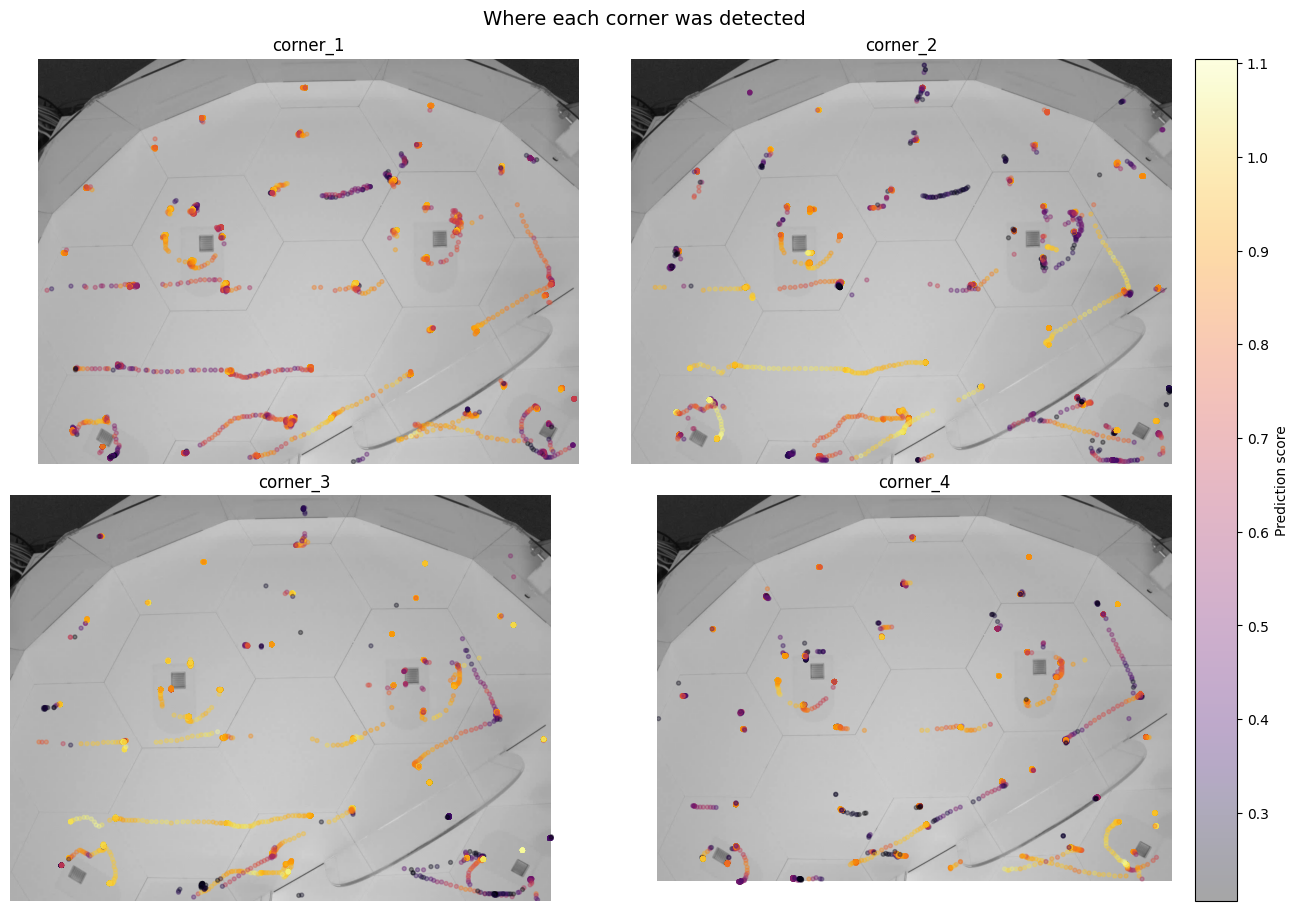

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
axes = axes.ravel()

node_order = ["corner_1", "corner_2", "corner_3", "corner_4"]

for ax, node_name in zip(axes, node_order):
    node_df = points_df[points_df["node_name"] == node_name]

    ax.imshow(frame_rgb)
    sc = ax.scatter(
        node_df["x"],
        node_df["y"],
        c=node_df["score"],
        s=8,
        alpha=0.35,
        cmap="inferno",
    )
    ax.set_title(node_name)
    ax.axis("off")

fig.suptitle("Where each corner was detected", fontsize=14)

cbar = fig.colorbar(sc, ax=axes, location="right", pad=0.02)
cbar.set_label("Prediction score")

plt.show()


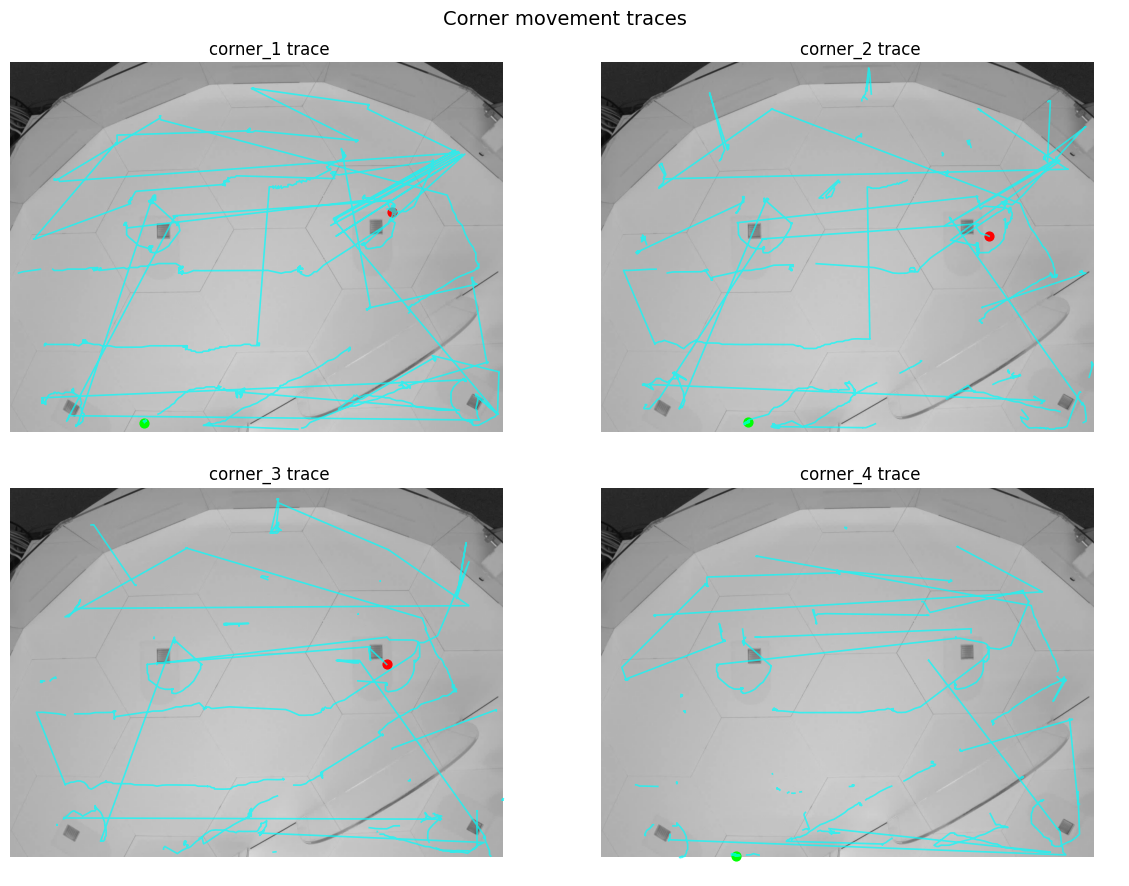

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axes = axes.ravel()

for ax, node_name in zip(axes, node_order):
    node_df = (
        points_df[points_df["node_name"] == node_name]
        .sort_values("frame_idx")
    )

    ax.imshow(frame_rgb)
    ax.plot(
        node_df["x"],
        node_df["y"],
        linewidth=1.2,
        alpha=0.7,
        color="cyan",
    )
    ax.scatter(
        node_df["x"].iloc[0],
        node_df["y"].iloc[0],
        color="lime",
        s=40,
        label="start",
    )
    ax.scatter(
        node_df["x"].iloc[-1],
        node_df["y"].iloc[-1],
        color="red",
        s=40,
        label="end",
    )
    ax.set_title(f"{node_name} trace")
    ax.axis("off")

fig.suptitle("Corner movement traces", fontsize=14)
plt.tight_layout()
plt.show()


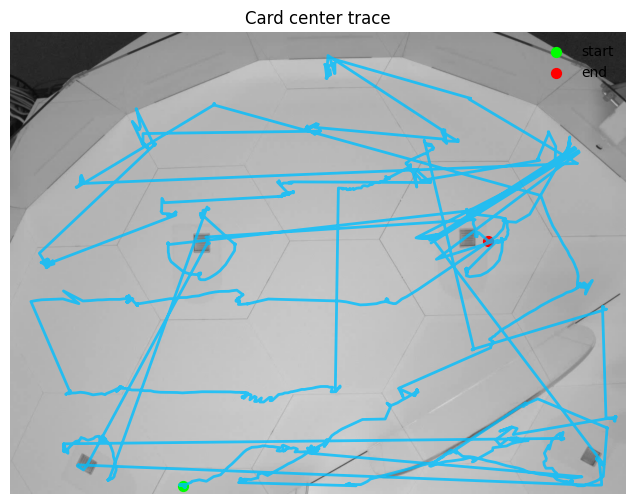

In [21]:
center_df = (
    points_df.groupby("frame_idx")[["x", "y"]]
    .mean()
    .reset_index()
    .sort_values("frame_idx")
)

plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.plot(center_df["x"], center_df["y"], color="deepskyblue", linewidth=2, alpha=0.8)
plt.scatter(center_df["x"].iloc[0], center_df["y"].iloc[0], color="lime", s=50, label="start")
plt.scatter(center_df["x"].iloc[-1], center_df["y"].iloc[-1], color="red", s=50, label="end")
plt.title("Card center trace")
plt.legend(frameon=False)
plt.axis("off")
plt.show()


In [31]:
point_rows = []

for lf in labels.labeled_frames:
    for inst_idx, inst in enumerate(lf.instances):
        for pt in inst.points:
            point_rows.append(
                {
                    "frame_idx": lf.frame_idx,
                    "instance_idx": inst_idx,
                    "node_name": pt["name"],
                    "score": float(pt["score"]),
                }
            )

points_df = pd.DataFrame(point_rows)


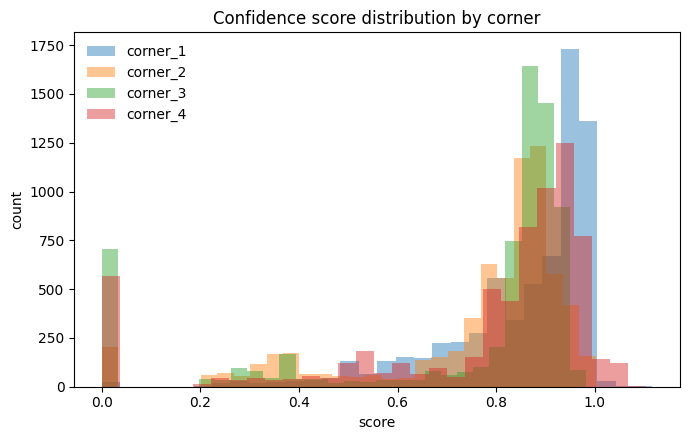

In [29]:
import matplotlib.pyplot as plt

node_colors = {
    "corner_1": "#1f77b4",
    "corner_2": "#ff7f0e",
    "corner_3": "#2ca02c",
    "corner_4": "#d62728",
}

plt.figure(figsize=(7, 4.5))

for node_name, color in node_colors.items():
    node_df = points_df[points_df["node_name"] == node_name]
    plt.hist(
        node_df["score"],
        bins=30,
        alpha=0.45,
        label=node_name,
        color=color,
    )

plt.title("Confidence score distribution by corner")
plt.xlabel("score")
plt.ylabel("count")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [ ]:
preview_path = EXPORT_DIR / "south_camera_preview_labeled.mp4"

sio.render_video(
    labels,
    save_path=preview_path,
    start=6093,
    end=6293,   # about 200 predicted frames
    preset="preview",
    scale=0.7,
    marker_size=5,
    line_width=2,
    show_edges=True,
    show_progress=True,
)

preview_path


Rendering: 100%|██████████| 167/167 [00:03<00:00, 48.17frame/s]


PosixPath('/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/south_camera_inference/exports/south_camera_preview_labeled.mp4')

In [ ]:
full_video_path = EXPORT_DIR / "south_camera_full_labeled.mp4"

sio.render_video(
    labels,
    save_path=full_video_path,
    preset="final",
    scale=1.0,
    marker_size=5,
    line_width=2,
    show_edges=True,
    show_progress=True,
)

full_video_path


Rendering: 100%|██████████| 6797/6797 [02:27<00:00, 46.00frame/s]


PosixPath('/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/south_camera_inference/exports/south_camera_full_labeled.mp4')

In [6]:
share_video_path = EXPORT_DIR / "south_camera_full_labeled_small.mp4"

sio.render_video(
    labels,
    save_path=share_video_path,
    preset="draft",
    scale=0.7,
    marker_size=4,
    line_width=2,
    crf=28,
    show_edges=True,
    show_progress=True,
)

share_video_path


Rendering: 100%|██████████| 6797/6797 [02:37<00:00, 43.21frame/s]


PosixPath('/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/south_camera_inference/exports/south_camera_full_labeled_small.mp4')